# Task 1 — Netflix Content Recommendation System

**Internship:** Auspify Technologies — Machine Learning

**Objective:** Build a content-based recommendation system that suggests Netflix titles similar to a selected title using genres, categories, and other content attributes.

This notebook follows the five workflow steps in the internship guide: (1) prepare content-related features, (2) convert text to machine-readable features, (3) calculate similarity scores, (4) generate recommendations, and (5) evaluate recommendation quality.

## 1. Import libraries

We use pandas for data handling, NumPy for numerical operations, and scikit-learn for TF-IDF feature extraction and cosine similarity. `TfidfVectorizer` converts raw documents into a TF-IDF feature matrix, while cosine similarity compares the resulting vectors.

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

## 2. Road dataset

In [3]:
df = pd.read_csv("C:/Users/USER/Downloads/Dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


### Dataset overview

The supplied dataset contains 8,790 Netflix titles and 10 columns. The main content fields for this recommendation task are `type`, `director`, `country`, `rating`, and `listed_in`. The title itself is kept as the identifier and is not used as a similarity feature.

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
df.isna().sum()

Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Missing values:


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

<Axes: xlabel='type'>

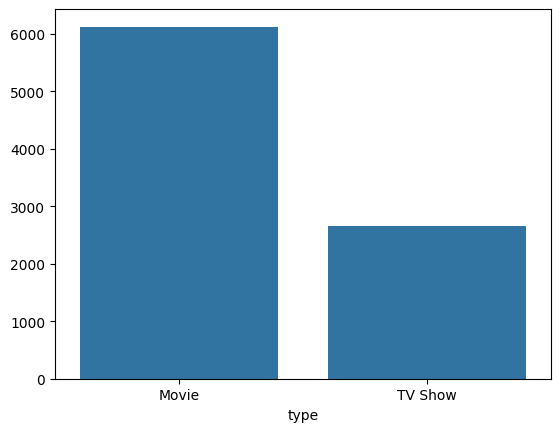

In [5]:
sns.barplot(x=df.type.value_counts().index, y=df.type.value_counts().values)

## 3. Prepare content-related features

The task requires content-related features. We combine the available descriptive fields into one text representation. Missing values are replaced with empty strings so they do not cause errors during text processing.

In [6]:
#Combining content features
df["content"] = (
    df["type"] + " " +
    df["director"] + " " +
    df["country"] + " " +
    df["rating"] + " " +
    df["listed_in"]
)
print("\nCombined content example:")
df[["title", "content"]].head()



Combined content example:


,title,content
0,Dick Johnson Is Dead,Movie Kirsten Johnson United States PG-13 Docu...
1,Ganglands,TV Show Julien Leclercq France TV-MA Crime TV ...
2,Midnight Mass,TV Show Mike Flanagan United States TV-MA TV D...
3,Confessions of an Invisible Girl,Movie Bruno Garotti Brazil TV-PG Children & Fa...
4,Sankofa,"Movie Haile Gerima United States TV-MA Dramas,..."


## 4. Convert text into machine-readable features with TF-IDF


Here we used TF-IDF which represents each title's combined content as a numerical vector. Common words receive less importance while terms that distinguish documents receive more weight. This is good for our case for comparing text-based content descriptions.

In [7]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["content"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of text features:", len(tfidf.get_feature_names_out()))

TF-IDF matrix shape: (8790, 6569)
Number of text features: 6569


## 5. Generate recommendations with cosine similarity

For efficiency, we calculate similarity only between the selected title and all other titles instead of constructing a full 8,790 × 8,790 dense similarity matrix. Cosine similarity is commonly used for TF-IDF document vectors.

In [8]:
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

def recommend(title, n=10):
    # Case-insensitive title lookup
    matches = df.index[df["title"].str.casefold() == title.casefold()].tolist()

    if not matches:
        return None

    idx = matches[0]
    scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).ravel()
    ranked_indices = np.argsort(-scores)
    ranked_indices = [i for i in ranked_indices if i != idx][:n]

    recommendations = df.iloc[ranked_indices][
        ["title", "type", "release_year", "rating", "listed_in"]
    ].copy()
    recommendations["Similarity Score"] = np.round(scores[ranked_indices], 3)
    return recommendations.reset_index(drop=True)

## 6. Test the recommendation system

The following example uses a title that exists in the supplied dataset.

In [9]:
selected_title = "Midnight Mass"
recommendations = recommend(selected_title, 10)

if recommendations is None:
    print("Title not found in the dataset.")
else:
    print(f"Recommendations for: {selected_title}")
    recommendations

Recommendations for: Midnight Mass


## 7. Search for a title before recommending

This helper makes the system easier to use when the user does not remember the exact title spelling.

In [10]:
def search_titles(keyword, limit=10):
    results = df[df["title"].str.contains(keyword, case=False, na=False)]
    return results[["title", "type", "release_year", "rating"]].head(limit)

search_titles("mass")

,title,type,release_year,rating
2,Midnight Mass,TV Show,2021,TV-MA
2567,The Massively Mixed-Up Middle School Mystery,Movie,2015,TV-Y
2936,ReMastered: The Miami Showband Massacre,Movie,2019,TV-MA
3077,ReMastered: Massacre at the Stadium,Movie,2019,TV-MA
6311,The Texas Chainsaw Massacre,Movie,1974,R


## 8. Evaluate recommendation quality

A content-based recommender does not have a conventional classification accuracy because there is no target label being predicted. For this task, we evaluate whether recommendations are content-relevant using similarity scores and genre overlap.

The genre-overlap metric below measures the proportion of recommended titles that share at least one category from `listed_in` with the selected title. This is a simple task-specific evaluation, not a universal benchmark for recommender systems.

In [11]:
def genre_overlap_evaluation(title, n=10):
    recommendations = recommend(title, n)
    if recommendations is None:
        return None

    source_rows = df.index[df["title"].str.casefold() == title.casefold()].tolist()
    source_genres = set(g.strip().casefold() for g in df.loc[source_rows[0], "listed_in"].split(",") if g.strip())

    overlaps = []
    for genres in recommendations["listed_in"]:
        rec_genres = set(g.strip().casefold() for g in genres.split(",") if g.strip())
        overlaps.append(bool(source_genres & rec_genres))

    return {
        "title": title,
        "recommendations_checked": len(recommendations),
        "genre_overlap_count": sum(overlaps),
        "genre_overlap_rate": round(np.mean(overlaps), 3) if overlaps else 0
    }

genre_overlap_evaluation("Midnight Mass", 10)

{'title': 'Midnight Mass',
 'recommendations_checked': 10,
 'genre_overlap_count': 7,
 'genre_overlap_rate': np.float64(0.7)}

## 9. Evaluate several sample titles
Checking multiple titles reduces the risk of judging the recommender from only one example.

In [12]:
sample_titles = ["Midnight Mass", "Sankofa", "The Starling"]

evaluation_results = []
for title in sample_titles:
    result = genre_overlap_evaluation(title, 10)
    if result is not None:
        evaluation_results.append(result)

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,title,recommendations_checked,genre_overlap_count,genre_overlap_rate
0,Midnight Mass,10,7,0.7
1,Sankofa,10,7,0.7
2,The Starling,10,5,0.5


## 10. Final conclusion

The system implements a content-based Netflix recommendation workflow using feature engineering, TF-IDF text representation, cosine similarity, and a simple relevance evaluation based on genre overlap. It can recommend titles similar to a selected Netflix title using the attributes available in the supplied dataset.

## Limitations;
1. cold-start problem; new user have no viewing/rating history
2. popularity bias; popular titles may dominate recommendations
3. no real-time recommendation system
## Furture Improvement;
1. Build a user-friendly interface; creating a streamlit application where user selects amovie/show and receives recommendations
2. Deep-learning recommendation models requiring large user-interaction datasets.